In [1]:
import os
from glob import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
# # Load training force and vf data
# force_dir = './data/one-contact-data-new/force'
# vf_dir = './data/one-contact-data-new/vf'

# force_files = sorted(glob(os.path.join(force_dir, '*.npy')))
# vf_files = sorted(glob(os.path.join(vf_dir, '*.npy')))

# # Load all training data into arrays
# force_data = np.array([np.load(f) for f in force_files], dtype=np.float32)
# vf_data = np.array([np.load(f) for f in vf_files], dtype=np.float32)

# print('Training Force shape:', force_data.shape)
# print('Training VF shape:', vf_data.shape)

# # Load test data
# test_force_dir = './data/test-data-new/force'
# test_vf_dir = './data/test-data-new/vf'

# test_force_files = sorted(glob(os.path.join(test_force_dir, '*.npy')))
# test_vf_files = sorted(glob(os.path.join(test_vf_dir, '*.npy')))

# # Load all test data into arrays
# test_force_data = np.array([np.load(f) for f in test_force_files], dtype=np.float32)
# test_vf_data = np.array([np.load(f) for f in test_vf_files], dtype=np.float32)

# print('Test Force shape:', test_force_data.shape)
# print('Test VF shape:', test_vf_data.shape)

# # Reshape force to (N, 1) if needed
# if force_data.ndim == 1:
#     force_data = force_data[:, None]
# if test_force_data.ndim == 1:
#     test_force_data = test_force_data[:, None]

# # Flatten vf for regression (N, C*H*W)
# N = vf_data.shape[0]
# vf_flat = vf_data.reshape(N, -1)

# N_test = test_vf_data.shape[0]
# test_vf_flat = test_vf_data.reshape(N_test, -1)

# print('Flattened training VF shape:', vf_flat.shape)
# print('Training Force shape:', force_data.shape)
# print('Flattened test VF shape:', test_vf_flat.shape)
# print('Test Force shape:', test_force_data.shape)

In [2]:
#  Load dataset from CSV: get 'wrench' -> force_data and load 'array_path' -> vf_flat
import pandas as pd
import ast

# Path to the dataset index
# csv_path = './data/temp_gelfoot_data/index.csv'
# csv_path = '/home/xili/ws/gelfoot_ws/src/tensegrity-gelfoot/data/index.csv'
csv_path = './data/index.csv'
# /home/xili/gelfoot_dataset/index.csv Read CSV
df = pd.read_csv(csv_path)

# Validate expected columns
required_cols = {'wrench', 'array_path'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in CSV: {missing}. Found columns: {list(df.columns)}")

# Resolve absolute file paths for arrays
base_dir = os.path.dirname(csv_path)
def resolve_path(p):
    return p if os.path.isabs(p) else os.path.join(base_dir, p)

paths = [resolve_path(p) for p in df['array_path'].astype(str).tolist()]

# Parse wrench column which is stored as a stringified list, e.g. "[fx, fy, fz, tx, ty, tz]"
def parse_wrench(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(map(float, x))
    if isinstance(x, str):
        try:
            v = ast.literal_eval(x)
            return list(map(float, v))
        except Exception as e:
            raise ValueError(f'Failed to parse wrench string: {x}\nError: {e}')
    # fallback: try float
    return [float(x)]

wrenches_list = [parse_wrench(x) for x in df['wrench'].tolist()]

# Ensure consistent shape: if scalar per row, make (N,1); if 6D vector, make (N,6)
max_len = max(len(w) for w in wrenches_list)
force_data = np.array([w if len(w)==max_len else (w + [0.0]*(max_len-len(w))) for w in wrenches_list], dtype=np.float32)

# Load arrays and keep only rows with existing files (synchronize lists)
arrays = []
valid_forces = []
valid_paths = []
for p, f in zip(paths, force_data):
    if not os.path.exists(p):
        print(f"Warning: array file not found, skipping: {p}")
        continue
    arr = np.load(p)
    arrays.append(arr.astype(np.float32))
    valid_forces.append(f)
    valid_paths.append(p)

if not arrays:
    raise RuntimeError('No arrays loaded. Please check the CSV paths and files.')

# Stack into a single numpy array
vf_data = np.stack(arrays, axis=0)  # expected shape (N, ... )
force_data = np.stack(valid_forces, axis=0).astype(np.float32)  # shape (N, D)

# Flatten vf for regression
vf_flat = vf_data.reshape(vf_data.shape[0], -1)

print('Loaded from CSV')
print('vf_data shape:', vf_data.shape)
print('vf_flat shape:', vf_flat.shape)
print('force_data shape:', force_data.shape)
print('Example path:', valid_paths[0] if len(valid_paths) > 0 else 'N/A')
print('First wrench:', force_data[0])

Loaded from CSV
vf_data shape: (34368, 2, 30, 30)
vf_flat shape: (34368, 1800)
force_data shape: (34368, 6)
Example path: ./data/shear_fields/000000.npy
First wrench: [-0.8902566   0.6276417   0.37713382 -0.00966864 -0.03505753  0.03218498]


In [3]:
# Prepare PyTorch datasets
X = torch.from_numpy(vf_flat).float()  # vf is input
Y = torch.from_numpy(force_data).float()  # force is label

# Check for GPU availability and move data to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

X = X.to(device)
Y = Y.to(device)

dataset = TensorDataset(X, Y)
# 0.8 split for training and testing
train_size = int(0.7 * len(dataset))
test_size = int(0.15 * len(dataset))
validation_size = len(dataset) - train_size - test_size

train_dataset, test_dataset, validation_dataset = torch.utils.data.random_split(dataset, [train_size, test_size, validation_size])

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=True)

print('Train size:', len(train_loader.dataset), 'Test size:', len(test_loader.dataset), 'Validation size:', len(validation_loader.dataset))

Using device: cuda
Train size: 24057 Test size: 5155 Validation size: 5156


Epoch 100, Train Loss: 0.1314, Test Loss: 0.1513


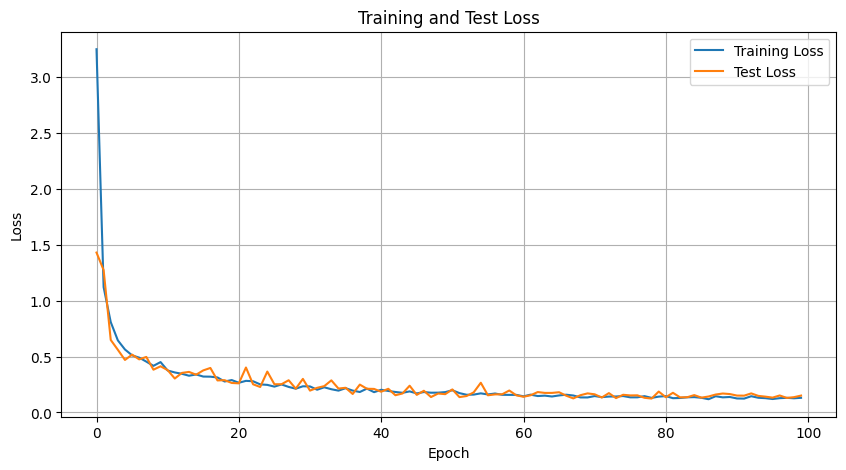

In [8]:
# Define a simple ResNet block
class ResBlock(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, out_features)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(out_features, out_features)
        self.shortcut = nn.Linear(in_features, out_features) if in_features != out_features else nn.Identity()
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out += self.shortcut(x)
        return self.relu(out)

# Define a simple ResNet for regression
class ResNetRegressor(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim=64, num_blocks=2):
        super().__init__()
        layers = [ResBlock(in_dim, hidden_dim)]
        for _ in range(num_blocks-1):
            layers.append(ResBlock(hidden_dim, hidden_dim))
        self.res_blocks = nn.Sequential(*layers)
        self.fc_out = nn.Linear(hidden_dim, out_dim)
        
    def forward(self, x):
        x = self.res_blocks(x)
        return self.fc_out(x)
    
class CNNRegressor(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_dim, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * (vf_data.shape[2] // 8) * (vf_data.shape[3] // 8), 32)
        self.fc2 = nn.Linear(32, out_dim)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = x.view(-1, 1, vf_data.shape[2], vf_data.shape[3])  # Reshape to (N, C, H, W)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Model, loss, optimizer - move model to GPU
in_dim = X.shape[1]
out_dim = Y.shape[1]
model = ResNetRegressor(in_dim, out_dim).to(device)
# model = CNNRegressor(in_dim, out_dim).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Function to evaluate model on test set
def evaluate_model(model, test_loader, loss_fn, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            total_loss += loss.item()
            num_batches += 1
    return total_loss / num_batches

# Training loop with testing
train_losses = []
test_losses = []

for epoch in range(100):
    # Training
    model.train()
    epoch_train_loss = 0
    train_batches = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)  # Move batch to GPU
        pred = model(xb)
        loss = loss_fn(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        train_batches += 1
    
    # Calculate average training loss
    avg_train_loss = epoch_train_loss / train_batches
    train_losses.append(avg_train_loss)
    
    # Testing
    avg_test_loss = evaluate_model(model, test_loader, loss_fn, device)
    test_losses.append(avg_test_loss)
    
print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

# Plot training and test losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.grid(True)
plt.show()

# save model
model_path = './checkpoints/wrench_regression_model.pth'
torch.save(model.state_dict(), model_path)

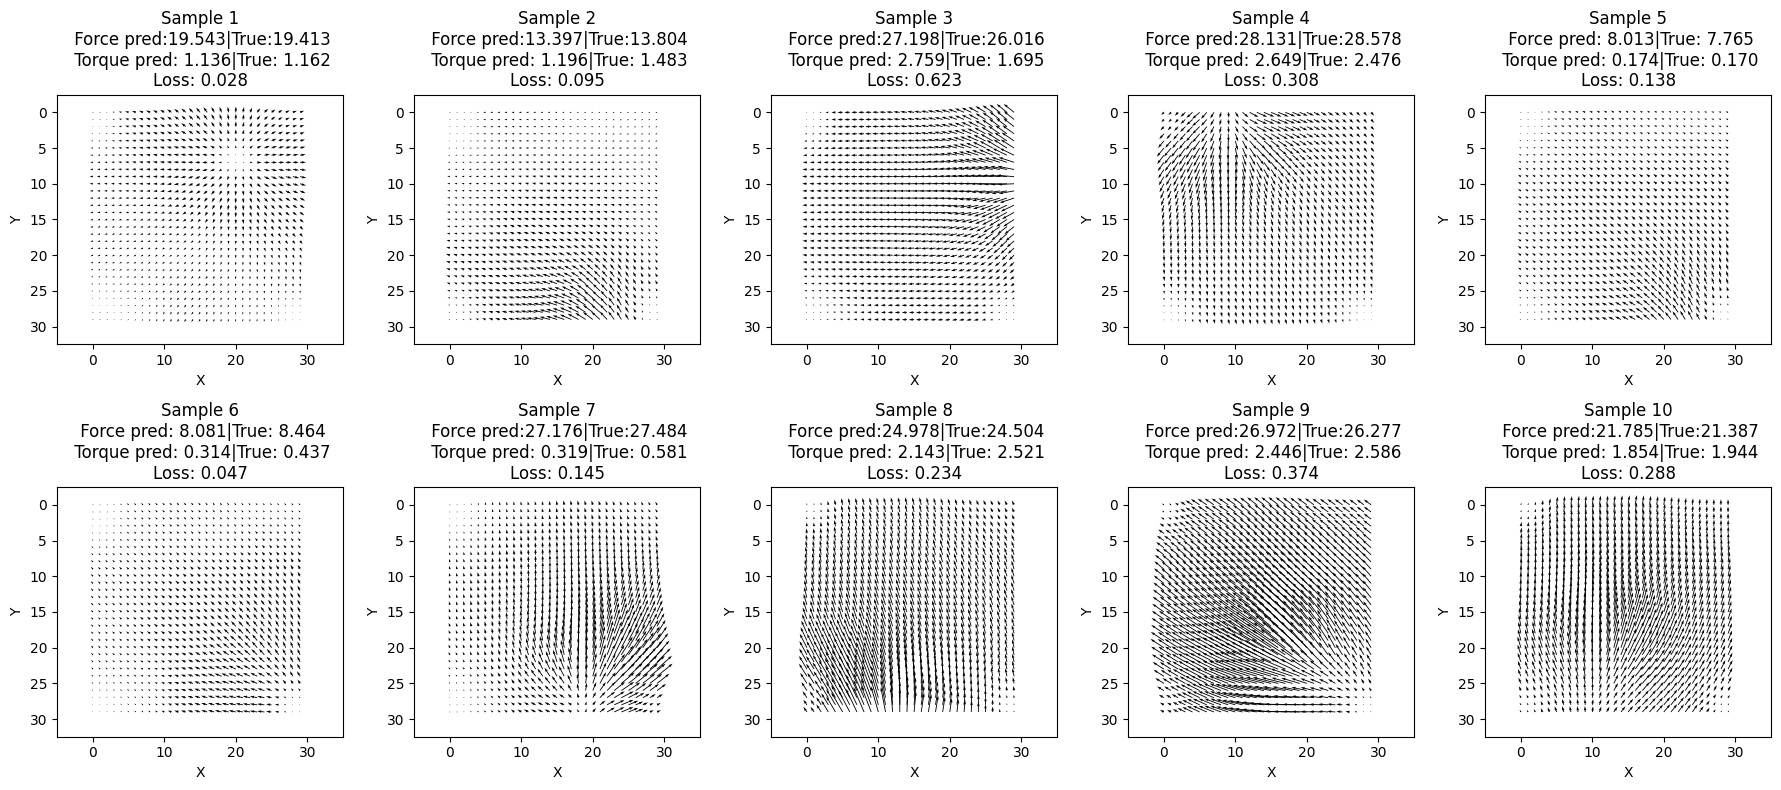

Sample 1: Predicted force: [ 5.3575425   4.2304606  18.311762   -0.9225661  -0.5895677   0.30410382] | Real force: [ 5.5645156   3.9383578  18.176521   -0.9747842  -0.4973635   0.39080298]
Sample 2: Predicted force: [-9.043149    8.649442    4.783863    0.4196148  -0.09194466  1.1164483 ] | Real force: [-8.91571     9.298018    4.95942     0.4912778  -0.27226144  1.3725181 ]
Sample 3: Predicted force: [ 1.6133702 22.81036   14.725546  -2.0118985 -0.9984059  1.602185 ] | Real force: [ 0.62780493 22.112604   13.692664   -1.3771188  -0.4977127   0.8528582 ]
Sample 4: Predicted force: [15.026132  -6.522167  22.869843  -1.0502496  2.1188114  1.1931416] | Real force: [15.9913025 -5.591728  23.015535  -0.964798   1.9790579  1.1332214]
Sample 5: Predicted force: [-7.3750124   2.9552536  -1.0407125  -0.11467596  0.1193049  -0.05511955] | Real force: [-6.8153734   3.6124527  -0.896417    0.04524082  0.10015357  0.12997124]
Sample 6: Predicted force: [-5.446683    5.958138    0.3777576   0.126331

In [ ]:
# Choose 10 random indices
num_samples = 10
indices = random.sample(range(len(X)), num_samples)

# Evaluate model on these samples
model.eval()
with torch.no_grad():
    X_samples = X[indices]
    Y_true = Y[indices]
   
Y_pred = model(X_samples)

# load from validation set
with torch.no_grad():
    X_samples = torch.stack([validation_dataset[i][0] for i in range(num_samples)]).to(device)
    Y_true = torch.stack([validation_dataset[i][1] for i in range(num_samples)]).to(device)
    Y_pred = model(X_samples)
    
# resampel if Y_true < 3 norm
while True:
    norms = torch.norm(Y_true, dim=1)
    if torch.all(norms >= 3.0):
        break
    for i in range(num_samples):
        if norms[i] < 3.0:
            idx = random.randint(0, len(validation_dataset)-1)
            X_samples[i] = validation_dataset[idx][0].to(device)
            Y_true[i] = validation_dataset[idx][1].to(device)
    with torch.no_grad():
        Y_pred = model(X_samples)

# Create a big plot with 10 subplots (2x5 grid)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i in range(num_samples):
    vf_input = X_samples[i].cpu().numpy().reshape(vf_data.shape[1:])
    force_pred = Y_pred[i].cpu().numpy()[:3]
    force_true = Y_true[i].cpu().numpy()[:3]
    torque_pred = Y_pred[i].cpu().numpy()[3:]
    torque_true = Y_true[i].cpu().numpy()[3:]
    force_pred_norm = np.linalg.norm(force_pred)
    force_true_norm = np.linalg.norm(force_true)
    torque_pred_norm = np.linalg.norm(torque_pred)
    torque_true_norm = np.linalg.norm(torque_true)
    loss = loss_fn(Y_pred[i], Y_true[i]).item()
    u = vf_input[0]
    v = vf_input[1]
    H, W = u.shape
    y, x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    
    axes[i].quiver(x, y, u, v, angles='xy', scale=1, scale_units='xy', width=0.003)
    axes[i].invert_yaxis()
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].axis('equal')
    axes[i].set_xlim(0, W)
    axes[i].set_ylim(H, 0)
    axes[i].set_title(f'Sample {i+1}\n Force pred:{force_pred_norm:6.3f}|True:{force_true_norm:6.3f}\n Torque pred:{torque_pred_norm:6.3f}|True:{torque_true_norm:6.3f}\nLoss:{loss:6.3f}')

plt.tight_layout()
plt.show()

# Print all results
for i in range(num_samples):
    force_pred = Y_pred[i].cpu().numpy()
    force_true = Y_true[i].cpu().numpy()
    print(f'Sample {i+1}: Predicted force: {force_pred} | Real force: {force_true}')

In [23]:
# Model, loss, optimizer - move model to GPU
in_dim = X.shape[1]
out_dim = Y.shape[1]
model = ResNetRegressor(in_dim, out_dim).to(device)
# model = CNNRegressor(in_dim, out_dim).to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [24]:
# load model for inference
model_path = './checkpoints/wrench_regression_model.pth'
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

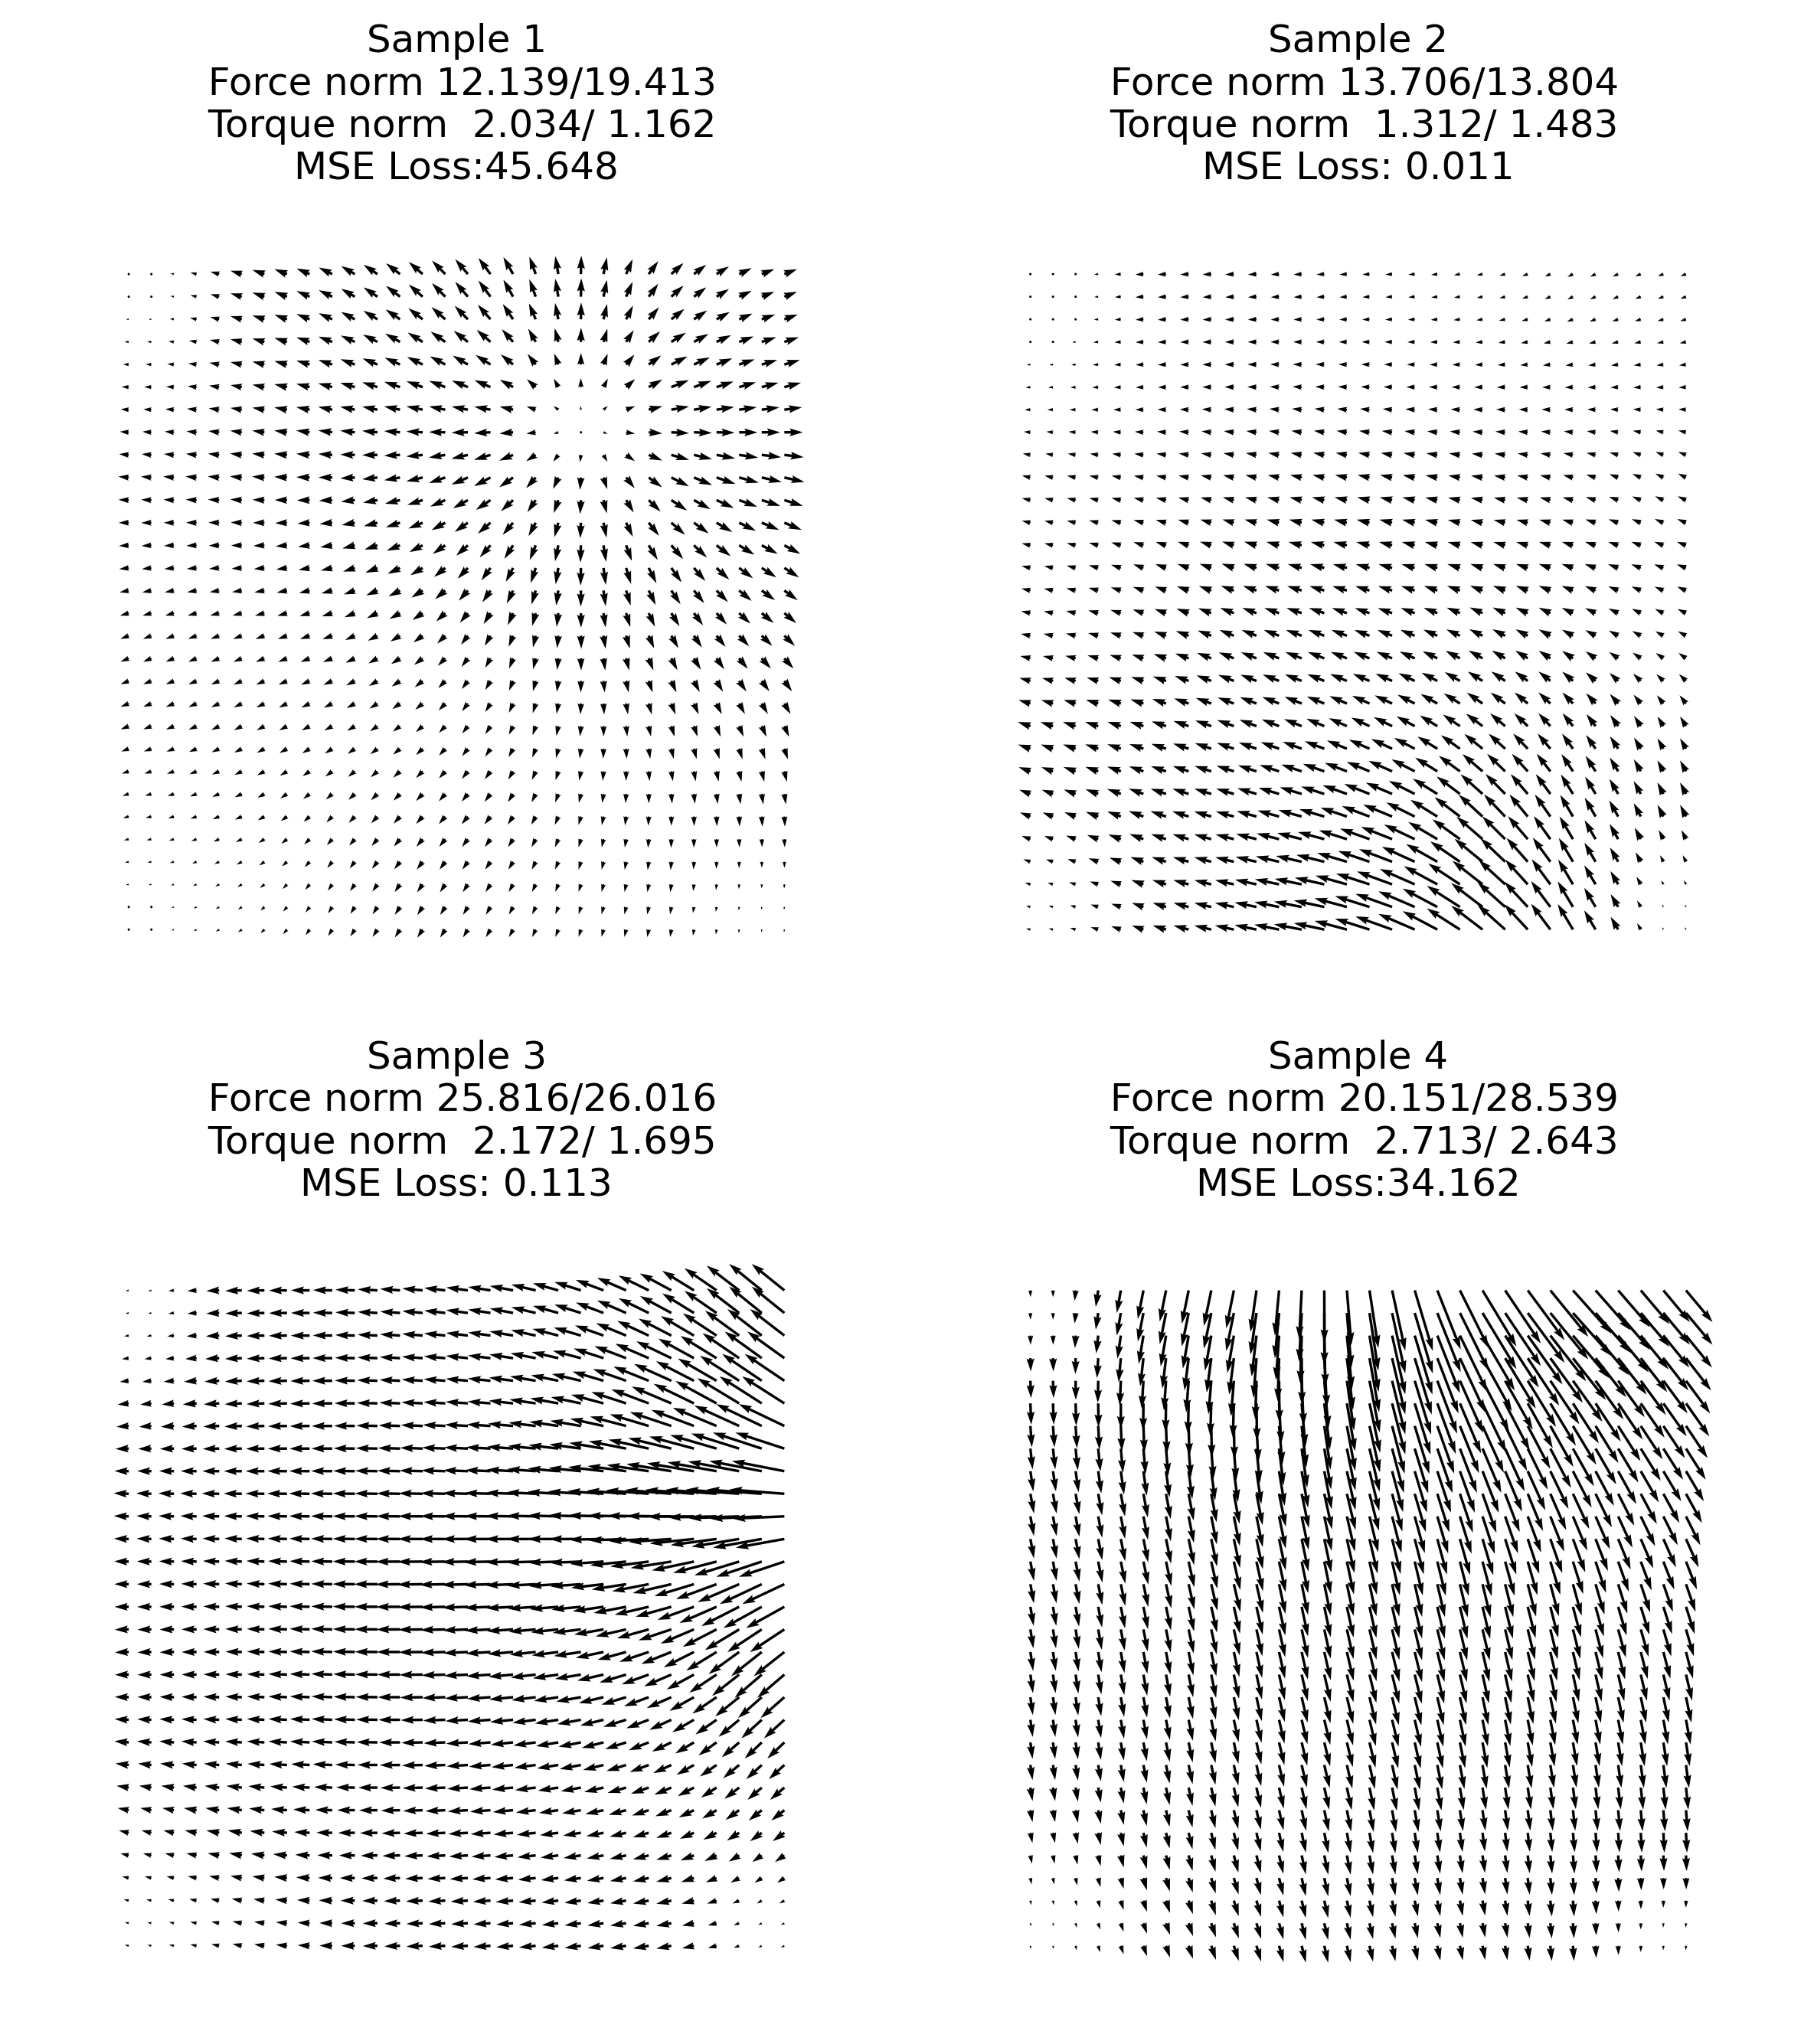

Sample 1: Predicted force: [-6.573924  -3.177852   9.697152   0.5177723 -1.524435   1.2426741] | Real force: [ 5.5645156   3.9383578  18.176521   -0.9747842  -0.4973635   0.39080298]
Sample 2: Predicted force: [-8.912354   9.137488   4.993536   0.3397123 -0.2304516  1.2456318] | Real force: [-8.91571     9.298018    4.95942     0.4912778  -0.27226144  1.3725181 ]
Sample 3: Predicted force: [ 1.1768787  21.936466   13.559129   -1.9387108  -0.39029318  0.8992073 ] | Real force: [ 0.62780493 22.112604   13.692664   -1.3771188  -0.4977127   0.8528582 ]
Sample 4: Predicted force: [14.665674    4.0659304  13.208121    0.40564445 -0.88176084  2.5336668 ] | Real force: [25.037958  -5.354637  12.606398  -0.5642965  1.7513266  1.8974949]


In [31]:
# Choose 10 random indices
num_samples = 4
indices = random.sample(range(len(X)), num_samples)

# load model
model.load_state_dict(torch.load(model_path))
model.to(device)

# Evaluate model on these samples
model.eval()

# load from validation set
with torch.no_grad():
    X_samples = torch.stack([validation_dataset[i][0] for i in range(num_samples)]).to(device)
    Y_true = torch.stack([validation_dataset[i][1] for i in range(num_samples)]).to(device)
    Y_pred = model(X_samples)
    
# resampel if Y_true < 3 norm
while True:
    norms = torch.norm(Y_true, dim=1)
    if torch.all(norms >= 3.0):
        break
    for i in range(num_samples):
        if norms[i] < 3.0:
            idx = random.randint(0, len(validation_dataset)-1)
            X_samples[i] = validation_dataset[idx][0].to(device)
            Y_true[i] = validation_dataset[idx][1].to(device)
    with torch.no_grad():
        Y_pred = model(X_samples)

# Create a big plot with 10 subplots (2x5 grid)
fig, axes = plt.subplots(2, 2, figsize=(8, 9), dpi=300)
axes = axes.flatten()

for i in range(num_samples):
    vf_input = X_samples[i].cpu().numpy().reshape(vf_data.shape[1:])
    force_pred = Y_pred[i].cpu().numpy()[:3]
    force_true = Y_true[i].cpu().numpy()[:3]
    torque_pred = Y_pred[i].cpu().numpy()[3:]
    torque_true = Y_true[i].cpu().numpy()[3:]
    force_pred_norm = np.linalg.norm(force_pred)
    force_true_norm = np.linalg.norm(force_true)
    torque_pred_norm = np.linalg.norm(torque_pred)
    torque_true_norm = np.linalg.norm(torque_true)
    loss = loss_fn(Y_pred[i], Y_true[i]).item()
    u = vf_input[0]
    v = vf_input[1]
    H, W = u.shape
    y, x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    
    axes[i].quiver(x, y, u, v, angles='xy', scale=1, scale_units='xy', width=0.003)
    axes[i].invert_yaxis()
    # axes[i].set_xlabel('X')
    # axes[i].set_ylabel('Y')
    axes[i].axis('equal')
    # axes[i].set_xlim(0, W)
    # axes[i].set_ylim(H, 0)
    # hide axis ticks
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    # hide axis boarder
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['bottom'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    axes[i].set_title(f'Sample {i+1}\n Force norm {force_pred_norm:6.3f}/{force_true_norm:6.3f}\n Torque norm {torque_pred_norm:6.3f}/{torque_true_norm:6.3f}\nMSE Loss:{loss:6.3f}')

plt.tight_layout()
plt.show()

# Print all results
for i in range(num_samples):
    force_pred = Y_pred[i].cpu().numpy()
    force_true = Y_true[i].cpu().numpy()
    print(f'Sample {i+1}: Predicted force: {force_pred} | Real force: {force_true}')

In [9]:
# evaluate on all validation set, print out average loss
model.eval()
total_loss = 0
num_batches = 0
with torch.no_grad():
    for xb, yb in validation_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        total_loss += loss.item()
        num_batches += 1
avg_validation_loss = total_loss / num_batches
print(f'Average validation loss: {avg_validation_loss:.4f}')



Average validation loss: 0.1629


In [26]:
force = Y.cpu().numpy()[:,:3]
torque = Y.cpu().numpy()[:,3:]

force_norm = np.linalg.norm(force, axis=1)
torque_norm = np.linalg.norm(torque, axis=1)

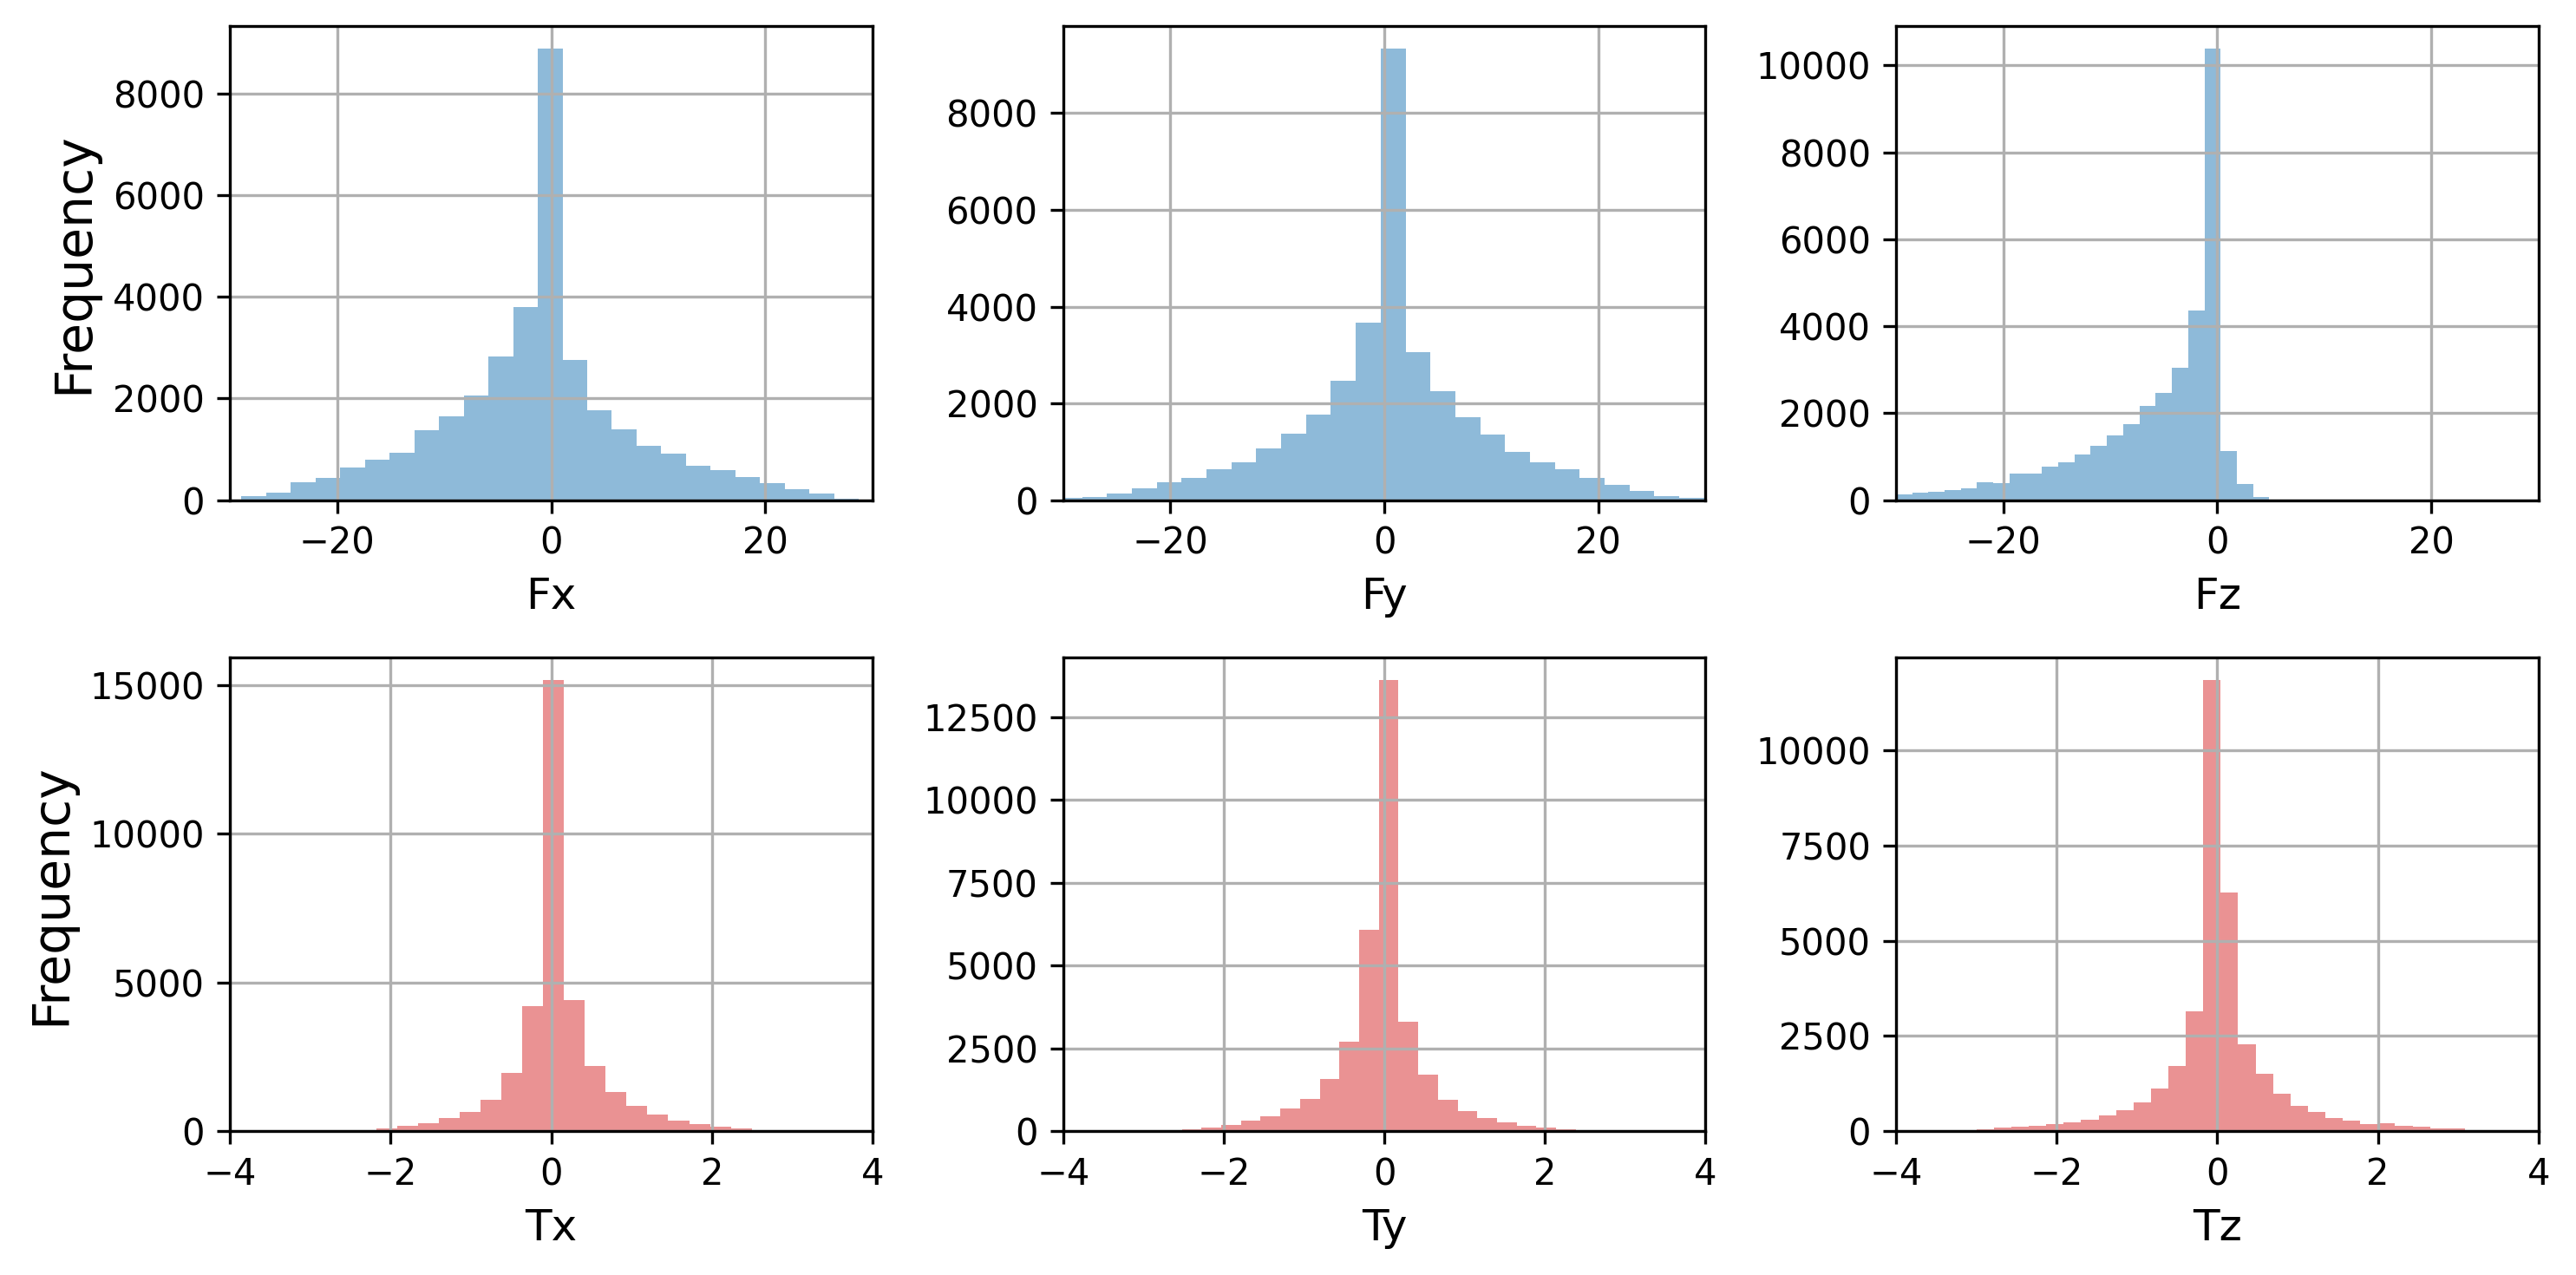

Fx: min=-33.570, max=35.662
Fy: min=-35.210, max=34.528
Fz: min=-36.102, max=9.407
Tx: min=-4.773, max=3.015
Ty: min=-3.014, max=4.348
Tz: min=-3.217, max=3.300


In [27]:
# X, Y, Z directional distributions for Force and Torque
# Requires 'force' and 'torque' computed as in the previous cell
fig, axes = plt.subplots(2, 3, figsize=(10, 5), dpi=300)
titles = ['X direction', 'Y direction', 'Z direction']
labels_force = ['Fx', 'Fy', 'Fz']
labels_torque = ['Tx', 'Ty', 'Tz']
colors_f = ['tab:blue', 'tab:blue', 'tab:blue']
colors_t = ['tab:red', 'tab:red', 'tab:red']

# for i, ax in enumerate(axes[0]):
#     ax.hist(force[:, i], bins=30, alpha=0.5, color=colors_f[i], label='Force')
#     ax.set_title(titles[i])
#     ax.set_xlabel(labels[i])
#     ax.set_ylabel('Frequency')
#     ax.set_xlim(-30, 30)
#     ax.grid(True)
#     ax.legend()
    
# for i, ax in enumerate(axes[1]):
#     ax.hist(torque[:, i], bins=30, alpha=0.5, color=colors_t[i], label='Torque')
#     ax.set_title(titles[i])
#     ax.set_xlabel(labels[i])
#     ax.set_ylabel('Frequency')
#     ax.set_xlim(-5, 5)
#     ax.grid(True)
#     ax.legend()
    
force_vis = np.copy(force)
force_vis[:,2] = -force[:,2]  # flip sign of Fz for better visualization
for i, ax in enumerate(axes[0]):
    ax.hist(force_vis[:, i], bins=30, alpha=0.5, color=colors_f[i], label='Force')
    # ax.set_title(titles[i])
    ax.set_xlabel(labels_force[i], fontsize=12)
    if i == 0:
        ax.set_ylabel('Frequency', fontsize=14)
    ax.set_xlim(-30, 30)
    ax.grid(True)
    # ax.legend()

tx, ty, tz = torque[:,0], torque[:,1], torque[:,2]
# randomly flip sign of tz for better visualization
for i in range(len(tz)):
    if random.random() > 0.5:
        tz[i] = -tz[i]
torque_vis = np.vstack((tx, ty, tz)).T
        
for i, ax in enumerate(axes[1]):
    ax.hist(torque_vis[:, i], bins=30, alpha=0.5, color=colors_t[i], label='Torque')
    # ax.set_title(titles[i])
    ax.set_xlabel(labels_torque[i], fontsize=12)
    if i == 0:
        ax.set_ylabel('Frequency', fontsize=14)
    ax.set_xlim(-4, 4)
    ax.grid(True)
    # ax.legend()

plt.tight_layout()
plt.show()

# printout max and min on each axis
for i, label in enumerate(['Fx', 'Fy', 'Fz']):
    print(f'{label}: min={force_vis[:,i].min():.3f}, max={force_vis[:,i].max():.3f}')
for i, label in enumerate(['Tx', 'Ty', 'Tz']):
    print(f'{label}: min={torque_vis[:,i].min():.3f}, max={torque_vis[:,i].max():.3f}')

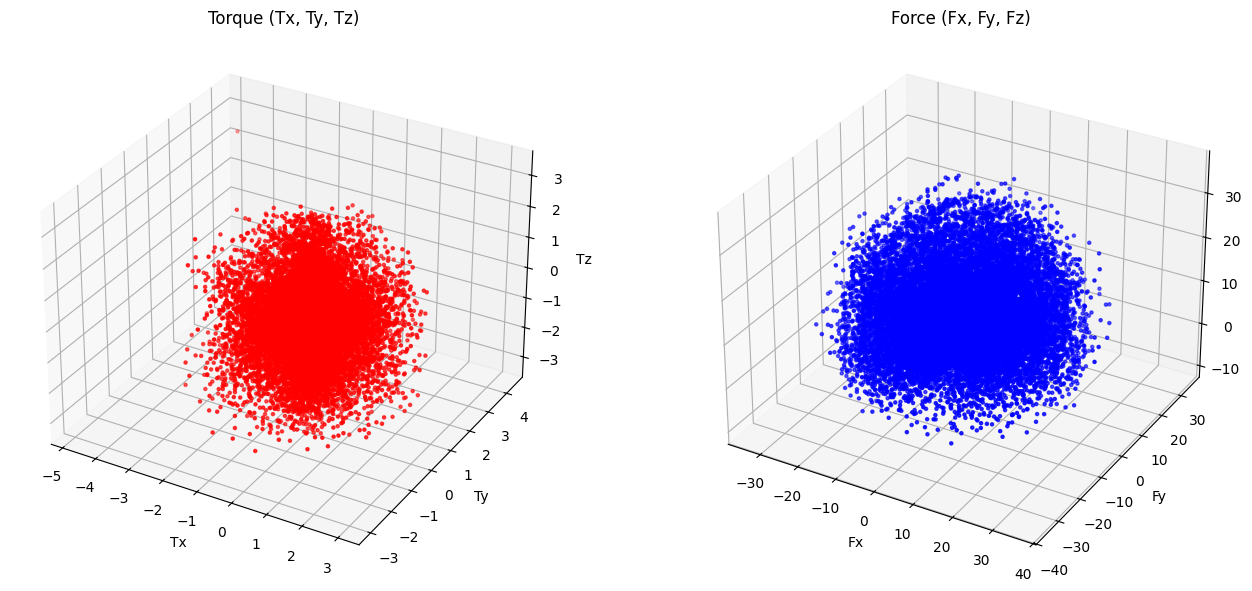

In [28]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Force and torque arrays already computed above
# Determine shared axis limits for comparability
mins = np.minimum(force.min(axis=0), torque.min(axis=0))
maxs = np.maximum(force.max(axis=0), torque.max(axis=0))

# Plot torque
ax1.scatter(torque[:,0], torque[:,1], torque[:,2], c='r', s=5)
ax1.set_title('Torque (Tx, Ty, Tz)')
ax1.set_xlabel('Tx')
ax1.set_ylabel('Ty')
ax1.set_zlabel('Tz')
# ax1.set_xlim(mins[0], maxs[0])
# ax1.set_ylim(mins[1], maxs[1])
# ax1.set_zlim(mins[2], maxs[2])

# Plot force
ax2.scatter(force[:,0], force[:,1], force[:,2], c='b', s=5)
ax2.set_title('Force (Fx, Fy, Fz)')
ax2.set_xlabel('Fx')
ax2.set_ylabel('Fy')
ax2.set_zlabel('Fz')
# ax2.set_xlim(mins[0], maxs[0])
# ax2.set_ylim(mins[1], maxs[1])
# ax2.set_zlim(mins[2], maxs[2])

plt.tight_layout()
plt.show()

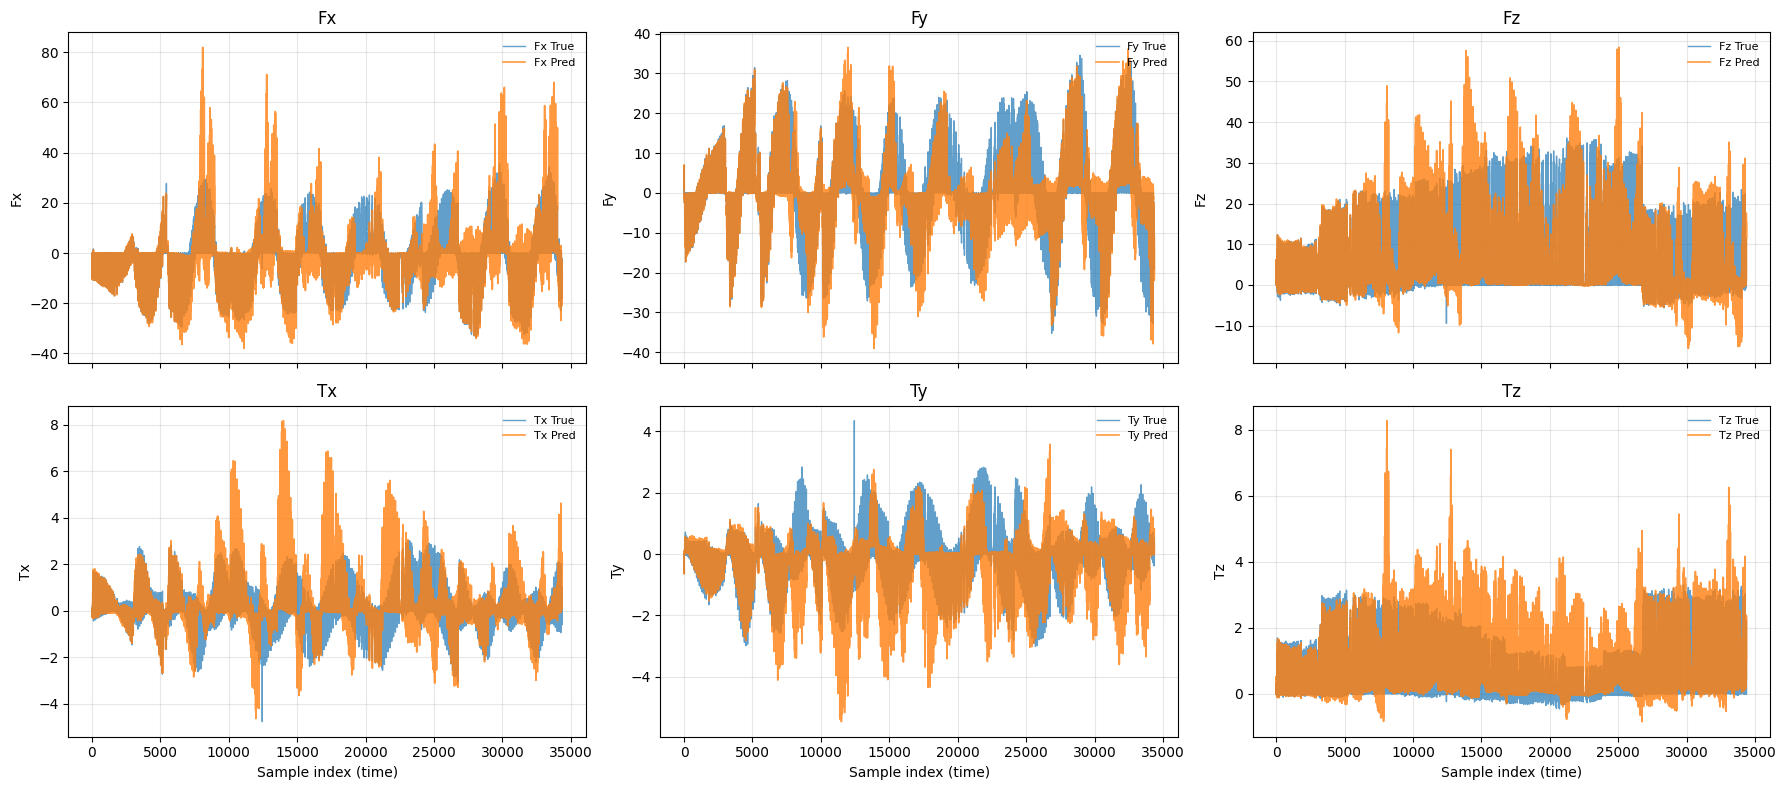

In [29]:
# Load trained model and generate continuous predictions; plot force/torque vs time
model_path = './checkpoints/wrench_regression_model.pth'

# Recreate the model architecture and load weights (state_dict)
in_dim = X.shape[1]
out_dim = Y.shape[1]
model = ResNetRegressor(in_dim, out_dim).to(device)
state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()

# Run inference over the entire dataset in order (treat index as time)
Y_pred_chunks = []
with torch.no_grad():
    infer_loader = DataLoader(TensorDataset(X, Y), batch_size=512, shuffle=False)
    for xb, _ in infer_loader:
        xb = xb.to(device)
        out = model(xb)
        Y_pred_chunks.append(out.cpu())

Y_pred = torch.cat(Y_pred_chunks, dim=0).numpy()
Y_true = Y.cpu().numpy()

# Plot per-component Force (Fx,Fy,Fz) and Torque (Tx,Ty,Tz) vs sample index (as time proxy)
import numpy as np
import matplotlib.pyplot as plt

labels = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']
t = np.arange(Y_true.shape[0])

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
for i, ax in enumerate(axes.flatten()):
    ax.plot(t, Y_true[:, i], label=f'{labels[i]} True', alpha=0.7, linewidth=1.0)
    ax.plot(t, Y_pred[:, i], label=f'{labels[i]} Pred', alpha=0.8, linewidth=1.2)
    ax.set_title(labels[i])
    ax.grid(True, alpha=0.3)
    if i >= 3:
        ax.set_xlabel('Sample index (time)')
    ax.set_ylabel(labels[i])
    ax.legend(loc='upper right', fontsize=8, frameon=False)

plt.tight_layout()
plt.show()